# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

# Sample EDA (Exploratory Data Analysis) Project:
Nothing but a data analysis attempt (actually my first ever). <br>
Dataset used: https://www.kaggle.com/datasets/fronkongames/steam-games-dataset/data - Steam store data<br>
Luckily for me, there was a missing comma in the header row inside the .csv file, which took me a while to realize.
### Goals:
* Find differences between platforms (which one dominates, tho one could assume it's going to be windows)
* Explore correlation between price and review scores
* Compare numbers of releases and average scores between years
* Study correlation between estimated owners and average playtime
* Check whether release date influences price (if newer releases could be considered more expensive)


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
print(pd.__version__)
print(np.__version__)

2.2.3
2.3.1


# Selection of relevant data

In [3]:
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Seaborn: {sns.__version__}")

usecols = ["AppID", "Name", "Release date", "Estimated owners", "Price", "Supported languages", "Windows", "Mac", "Linux", "Metacritic score", "User score", "Achievements", "Average playtime forever", "Categories", "Genres"]
df = pd.read_csv("games.csv", usecols=usecols, sep=",", header=0)


print(df.info())

Pandas: 2.2.3
NumPy: 2.3.1
Seaborn: 0.13.2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122611 entries, 0 to 122610
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AppID                     122611 non-null  int64  
 1   Name                      122610 non-null  object 
 2   Release date              122611 non-null  object 
 3   Estimated owners          122611 non-null  object 
 4   Price                     122611 non-null  float64
 5   Supported languages       122611 non-null  object 
 6   Windows                   122611 non-null  bool   
 7   Mac                       122611 non-null  bool   
 8   Linux                     122611 non-null  bool   
 9   Metacritic score          122611 non-null  int64  
 10  User score                122611 non-null  int64  
 11  Achievements              122611 non-null  int64  
 12  Average playtime forever  122611 non-null  int64  
 13  C

In [4]:
df["Release date"]=pd.to_datetime(df["Release date"], errors="coerce")
df=df.dropna(subset=['Name'])
df=df.dropna(subset=['Release date'])
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 122610 entries, 0 to 122610
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   AppID                     122610 non-null  int64         
 1   Name                      122610 non-null  object        
 2   Release date              122610 non-null  datetime64[ns]
 3   Estimated owners          122610 non-null  object        
 4   Price                     122610 non-null  float64       
 5   Supported languages       122610 non-null  object        
 6   Windows                   122610 non-null  bool          
 7   Mac                       122610 non-null  bool          
 8   Linux                     122610 non-null  bool          
 9   Metacritic score          122610 non-null  int64         
 10  User score                122610 non-null  int64         
 11  Achievements              122610 non-null  int64         
 12  Average

# Comparing NO. of releases for each platform:

Windows    122566
Mac         21292
Linux       15706
dtype: int64


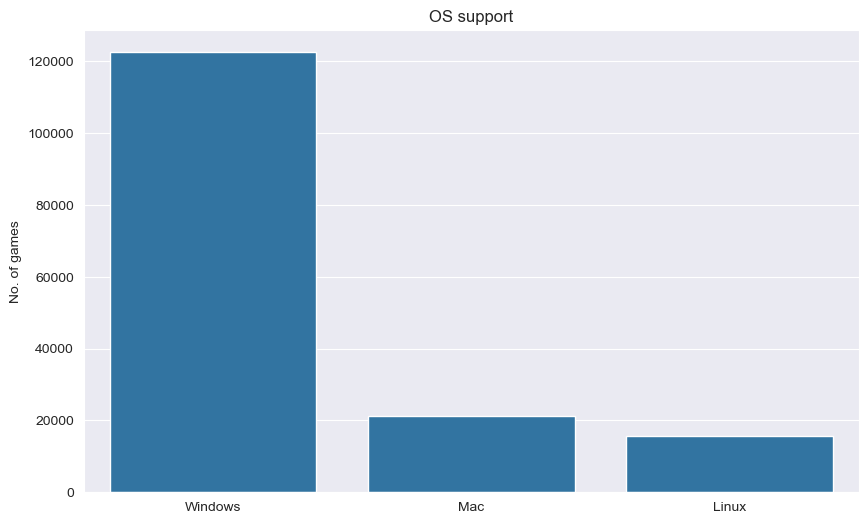

In [5]:
platforms = df[['Windows', 'Mac', 'Linux']].sum()
print(platforms)

plt.figure(figsize=(10, 6))
sns.barplot(x=platforms.index, y=platforms.values)
plt.title('OS support')
plt.xlabel('')
plt.ylabel('No. of games')
plt.show()

It was quite predictable that Windows was going to dominate the field although it's worth mentioning that not ALL of the games are supported on it

# Exploring the relationship between price and metacritic scores
##### !A score of 0 is considered as NotGiven!
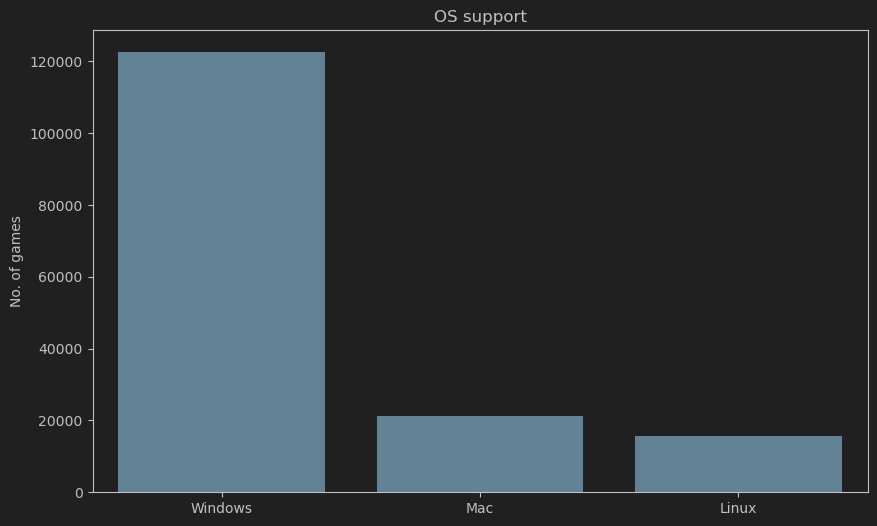

### Metacritic scores(price):

No. records:  4022


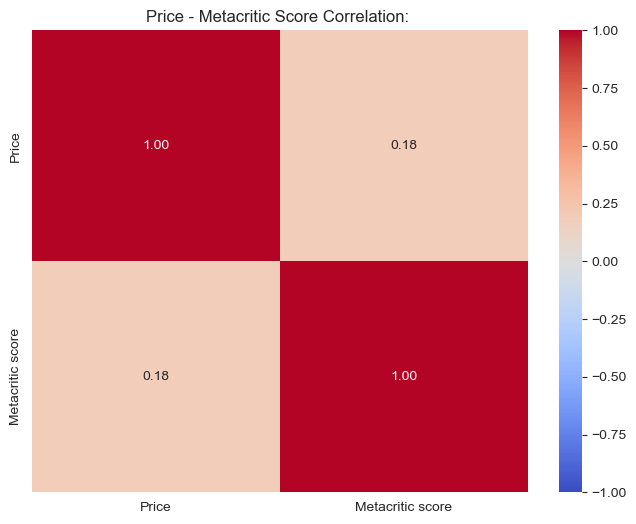

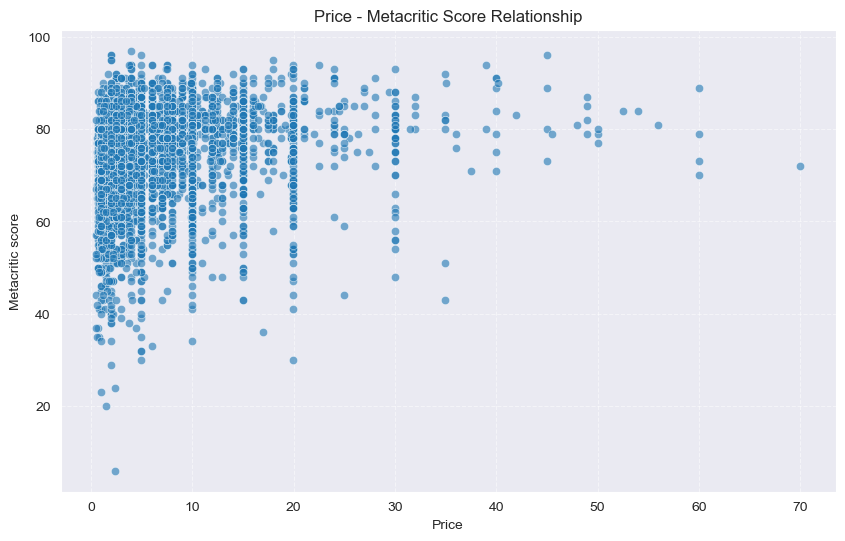

In [16]:
df_price_metacritic = df[(df['Price'] > 0) & (df['Metacritic score'] > 0)]

print("No. records: ", len(df_price_metacritic))

corr_matrix = df_price_metacritic[['Price', 'Metacritic score']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Price - Metacritic Score Correlation: ')


plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_price_metacritic, x='Price', y='Metacritic score', alpha=0.6)
plt.title('Price - Metacritic Score Relationship')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Only a relatively small amount of records had a Meta score > 0 (4k out of 120k). One could say that it makes most of the games available on steam rather "niche". "Niche" enough to not grab gaming media's interest <br>
Our correlation matrix calculated for this sample shows that there is no correlation between these two.
<br> We can dive a bit deeper and check how price differs between games with __really high__ review scores (>80):

No. records:  1076


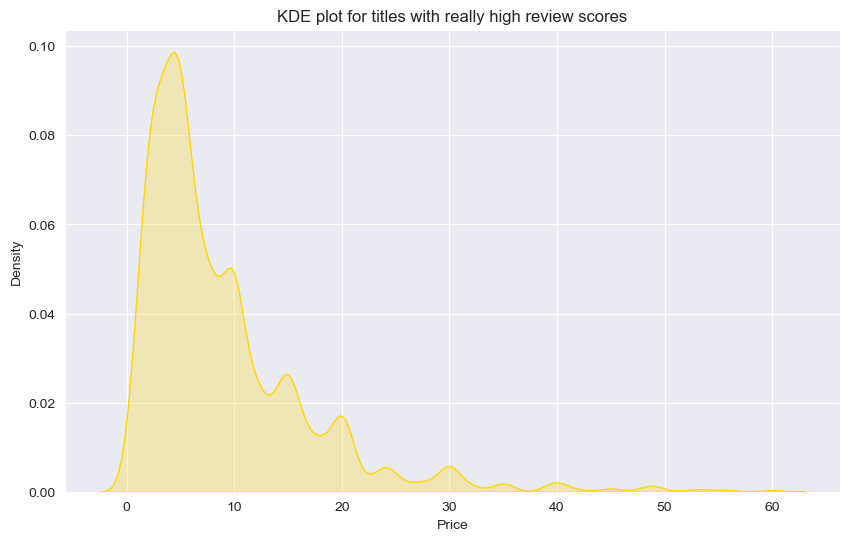

Mode:  0    4.99
Name: Price, dtype: float64
Median:  5.99


In [26]:
df_price_metacritic=df_price_metacritic[df_price_metacritic['Metacritic score']>80]
print("No. records: ", len(df_price_metacritic))

plt.figure(figsize=(10, 6))

sns.kdeplot(data=df_price_metacritic, x='Price', fill=True, bw_adjust=0.5, color='gold')
plt.title('KDE plot for titles with really high review scores')
plt.show()
print("Mode: ", df_price_metacritic['Price'].mode())
print("Median: ", df_price_metacritic['Price'].median())

Based on available data we can say that the "average" very positively reviewed game costs up to 10 USD (Seems like indie games are winning critics' hearts over AAA games). <br>
It is worth mentioning that there is visible skewness to the right. <br>
What's also interesting is that we can see spikes at a few price points which might be connected to the fact that most devs publish games at popular prices we usually see on the main store page such as [USD] 4.99; 7.99; 9.99; 14.99; 17.99; 19.99 etc. I believe these prices correspond with results from many psychological studies about what buyers think (I believe it also connects with the prices we see in real stores)

### User scores(price):

In [ ]:
df_price_users = df[(df['Price'] > 0) & (df['User score'] > 0)]
print(df_price_users.info(), df_price_users.head(5))